# Задание 4. Загрузка и исследование данных


In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import warnings
import time
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, roc_curve, confusion_matrix,
                           classification_report)

In [150]:
file_path = 'diabetes.csv'  
diabetes_df = pd.read_csv(file_path)

In [151]:
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Описание
* ### Структура данных:
    * 768 наблюдений (строк)
    * 9 переменных (столбцов), из которых:
    * 8 числовых признаков-предикторов
    * 1 целевая бинарная переменная

* ### Переменные:
    * Pregnancies - Количество беременностей
    * Glucose - Уровень глюкозы в плазме 
    * BloodPressure - Артериальное давление 
    * SkinThickness - Толщина кожной складки трицепса 
    * Insulin - Инсулин 
    * BMI - Индекс массы тела 
    * DiabetesPedigreeFunction - Функция наследственной предрасположенности к диабету
    * Age - Возраст 
    * Outcome - Целевая переменная (0 = нет диабета, 1 = есть диабет)

In [152]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# Описание
* Объём: 768 полных записей
* Признаки: 9 переменных
* Пропуски: отсутствуют (все 768 non-null)
### Типы данных:
* Целочисленные (int64): 7 столбцов
* Вещественные (float64): 2 столбца (BMI, DiabetesPedigreeFunction)

In [153]:
diabetes_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [154]:
print("АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ:")

total_cells = np.prod(diabetes_df.shape)
total_missing = diabetes_df.isnull().sum().sum()
missing_percentage = (total_missing / total_cells) * 100

print(f"Всего ячеек в датасете: {total_cells}")
print(f"Всего пропущенных значений: {total_missing}")
print(f"Процент пропусков: {missing_percentage:.2f}%")

if total_missing.sum() > 0:
    plt.figure(figsize=(12, 6))
    sns.heatmap(diabetes_df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
    plt.title('Карта пропущенных значений в датасете', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("\n В датасете нет пропущенных значений!")

АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ:
Всего ячеек в датасете: 6912
Всего пропущенных значений: 0
Процент пропусков: 0.00%

 В датасете нет пропущенных значений!


Данные в норме, представлены качественно, пропусков нет

# Задание 5. Корреляционный анализ

Построение тепловой карты корреляций для всех числовых признаков с помощью библиотеки Seaborn (heatmap)

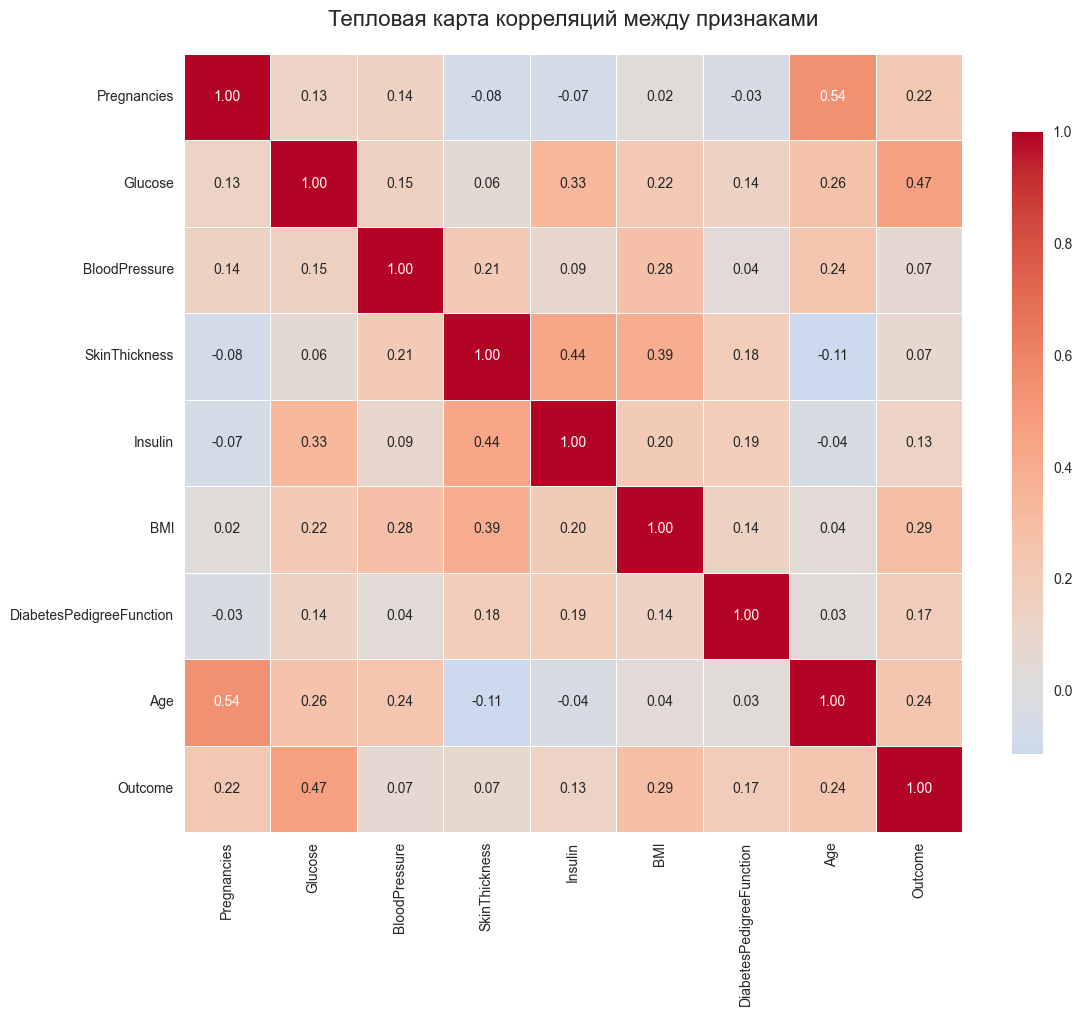

In [155]:
correlation_matrix = diabetes_df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))


heatmap = sns.heatmap(
    correlation_matrix,
    annot=True,          
    fmt='.2f',           
    cmap='coolwarm',    
    center=0,            
    square=True,        
    linewidths=0.5,      
    cbar_kws={'shrink': 0.8}  
)

plt.title('Тепловая карта корреляций между признаками', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

Анализ корреляции признаков

In [156]:
# Корреляция с целевой переменной Outcome
outcome_correlations = correlation_matrix['Outcome'].sort_values(ascending=False)
significant_features = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'Outcome']

print("Корреляции признаков с наличием диабета (Outcome):")
print("=" * 50)
for feature, corr_value in outcome_correlations.items():
    if feature != 'Outcome':
        print(f"{feature:30} : {corr_value:+.3f}")
        
# Наиболее коррелирующие признаки между собой
print("\nНаиболее сильные корреляции между признаками:")
print("=" * 50)
strong_correlations = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        feature1 = correlation_matrix.columns[i]
        feature2 = correlation_matrix.columns[j]
        corr = abs(correlation_matrix.iloc[i, j])
        if corr > 0.5:  # Порог для сильной корреляции
            strong_correlations.append((feature1, feature2, correlation_matrix.iloc[i, j]))

# Сортировка по убыванию абсолютной величины корреляции
strong_correlations.sort(key=lambda x: abs(x[2]), reverse=True)
for feat1, feat2, corr in strong_correlations[:5]:
    print(f"{feat1:20} & {feat2:20} : {corr:+.3f}")

Корреляции признаков с наличием диабета (Outcome):
Glucose                        : +0.467
BMI                            : +0.293
Age                            : +0.238
Pregnancies                    : +0.222
DiabetesPedigreeFunction       : +0.174
Insulin                        : +0.131
SkinThickness                  : +0.075
BloodPressure                  : +0.065

Наиболее сильные корреляции между признаками:
Pregnancies          & Age                  : +0.544


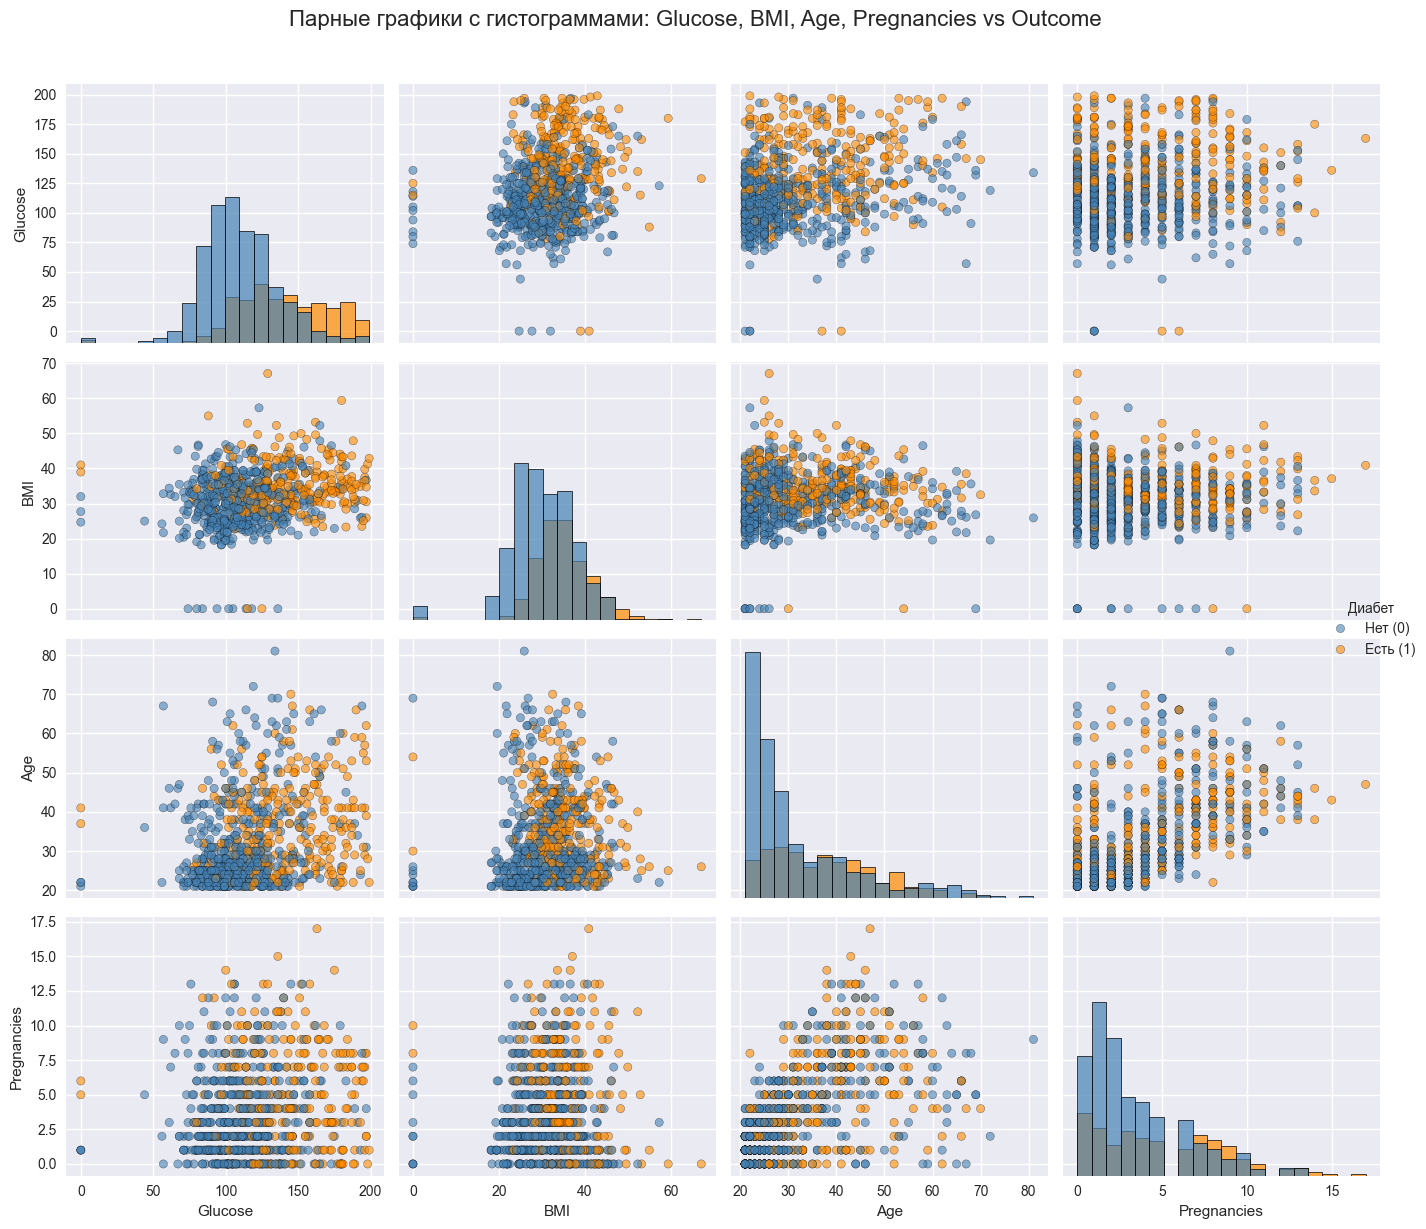

In [157]:
# Альтернативный вариант с гистограммами на диагонали
pairplot2 = sns.pairplot(
    data=diabetes_df[significant_features],
    hue='Outcome',
    palette={0: 'steelblue', 1: 'darkorange'},
    diag_kind='hist',  # Используем гистограммы на диагонали
    diag_kws={
        'alpha': 0.7,
        'bins': 20,
        'edgecolor': 'black',
        'linewidth': 0.5,
        'multiple': 'layer'  # Накладываем гистограммы друг на друга
    },
    plot_kws={
        'alpha': 0.6,
        's': 35,
        'edgecolor': 'black',
        'linewidth': 0.3
    }
)

# Устанавливаем размер фигуры через figsize в pairplot
pairplot2.fig.set_size_inches(14, 12)

# Настраиваем легенду
pairplot2._legend.set_title('Диабет')
pairplot2._legend.get_texts()[0].set_text('Нет (0)')
pairplot2._legend.get_texts()[1].set_text('Есть (1)')
pairplot2._legend.set_bbox_to_anchor((1.02, 0.5))  # Перемещаем легенду

# Добавляем заголовок
pairplot2.fig.suptitle(
    'Парные графики с гистограммами: Glucose, BMI, Age, Pregnancies vs Outcome',
    fontsize=16,
    y=1.02
)

# Улучшаем отображение
plt.tight_layout()
plt.show()

Визуализация распределения для каждого важного признака

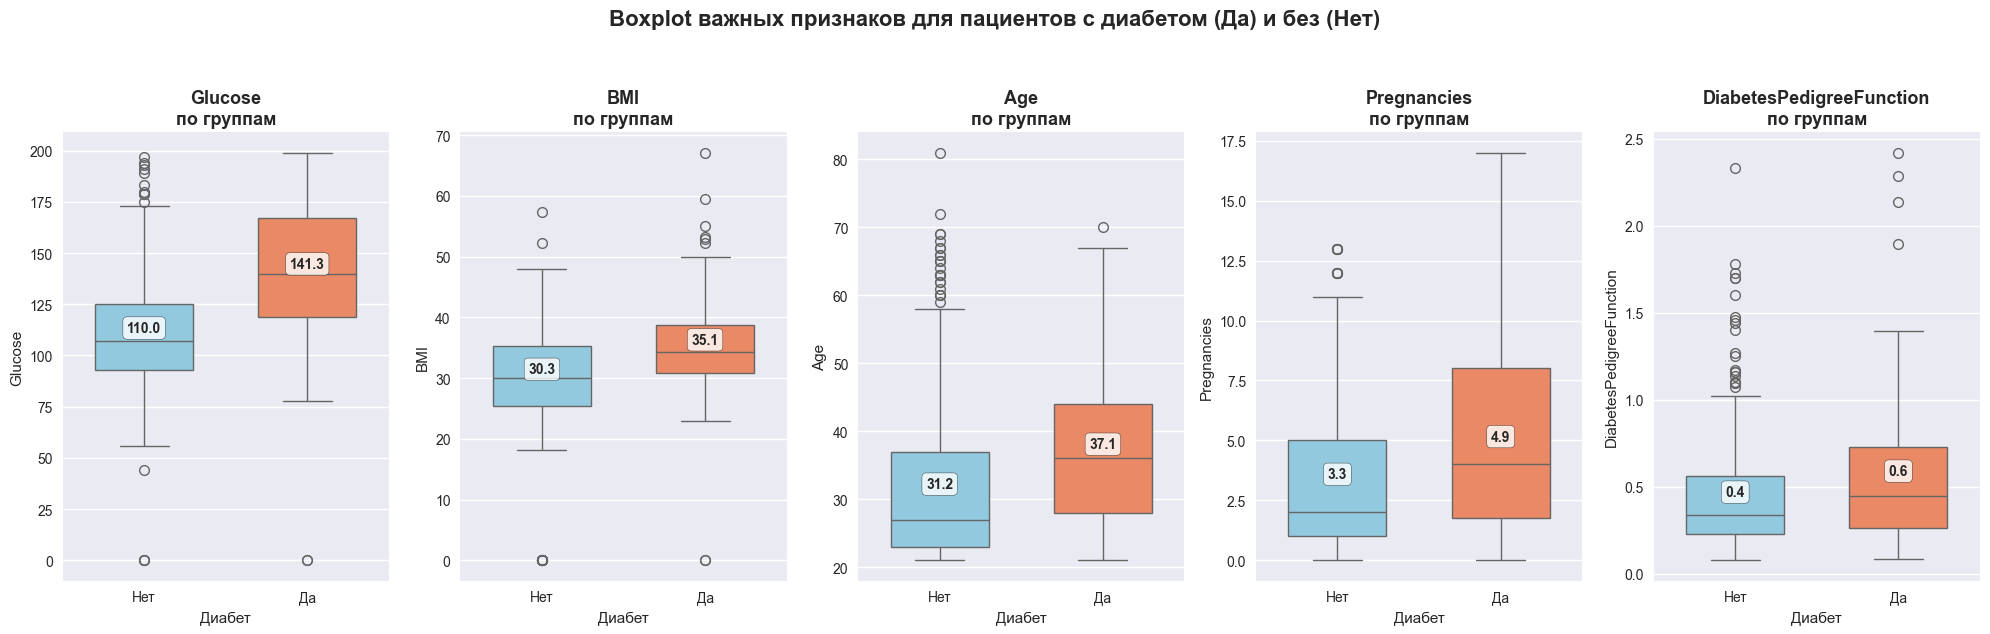

In [158]:
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
colors = ['skyblue', 'coral']  # или ['#3498db', '#e74c3c']
for idx, feature in enumerate(important_features):
    ax = axes[idx]
    
    sns.boxplot(
        data=diabetes_df,
        x='Outcome',
        y=feature,
        hue='Outcome',
        palette=colors,
        ax=ax,
        width=0.6,
        legend=False
    )
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Нет', 'Да'])
    ax.set_xlabel('Диабет', fontsize=11)
    ax.set_ylabel(feature, fontsize=11)
    ax.set_title(f'{feature}\nпо группам', fontsize=13, fontweight='bold')
    means = diabetes_df.groupby('Outcome')[feature].mean()
    for i, mean_val in enumerate(means):
        ax.text(i, mean_val, f'{mean_val:.1f}', 
                ha='center', va='bottom', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


plt.suptitle('Boxplot важных признаков для пациентов с диабетом (Да) и без (Нет)', 
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## Вывод
### Сильная положительная корреляция с наличием диабета (Outcome):
**Glucose (глюкоза)**: +0.47 — самая сильная связь  
Почему: Уровень глюкозы в крови — прямой диагностический критерий диабета. Значения выше 126 мг/дл натощак являются клиническим порогом для диагноза. Это причинно-следственная связь, а высокий уровень глюкозы — не признак, а суть заболевания.
### Умеренные положительные корреляции:
**BMI (индекс массы тела)**: +0.29  
Почему: Ожирение — ключевой фактор риска инсулинорезистентности, которая лежит в основе диабета 2 типа. Но при этом не все люди с ожирением заболевают диабетом, и не все диабетики имеют ожирение. Также влияют генетика, образ жизни, возраст.  
**Age (возраст)**: +0.24  
Почему: Риск диабета 2 типа увеличивается с возрастом из-за снижения чувствительности к инсулину, изменения состава тела, накопления висцерального жира. Но в выборке присутствуют как молодые пациенты с диабетом (возможно, тип 1 или гестационный), так и пожилые без диабета.  
**Pregnancies (беременности)**: +0.22  
Почему: Многократные беременности повышают риск гестационного диабета, который может перейти в диабет 2 типа. Также гормональные изменения влияют на метаболизм.  
### Слабые корреляции:
**Insulin (инсулин)**: +0.13  
Контр-интуитивный результат: Ожидалась отрицательная корреляция (низкий инсулин при диабете).  
Почему: При диабете 2 типа часто наблюдается гиперинсулинемия (повышенный инсулин) из-за инсулинорезистентности. Только на поздних стадиях истощаются β-клетки.  
**BloodPressure (давление)**: +0.07  
Почему: Эти признаки являются скорее следствиями или сопутствующими состояниями, а не прямыми причинами диабета.  

# Задание 6. Подготовка данных для обучения моделей

Выделение обучающих признаков — все, кроме Outcome, обозначение данных этого признака буквой X.

In [159]:
X = diabetes_df.drop('Outcome', axis=1)
y = diabetes_df['Outcome']


print("ОБУЧАЮЩИЕ ПРИЗНАКИ (X):")
print("=" * 60)
print(f"Количество признаков: {X.shape[1]}")
print(f"Названия признаков: {list(X.columns)}")

print("\nЦЕЛЕВОЙ ПРИЗНАК (y):")
print("=" * 60)
print(f"Название целевого признака: Outcome")
print(f"Размерность y: {y.shape}")

ОБУЧАЮЩИЕ ПРИЗНАКИ (X):
Количество признаков: 8
Названия признаков: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

ЦЕЛЕВОЙ ПРИЗНАК (y):
Название целевого признака: Outcome
Размерность y: (768,)


In [160]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3,        
    random_state=42,      
    stratify=y           
)

print("=" * 60)
print("РАЗДЕЛЕНИЕ ДАННЫХ")
print("=" * 60)
print(f"Размер обучающей выборки (X_train): {X_train.shape}")
print(f"Размер тестовой выборки (X_test): {X_test.shape}")
print(f"Размер y_train: {y_train.shape}")
print(f"Размер y_test: {y_test.shape}")

РАЗДЕЛЕНИЕ ДАННЫХ
Размер обучающей выборки (X_train): (537, 8)
Размер тестовой выборки (X_test): (231, 8)
Размер y_train: (537,)
Размер y_test: (231,)


In [161]:
scaler = StandardScaler()

print("\n" + "=" * 60)
print("МАСШТАБИРОВАНИЕ ПРИЗНАКОВ")
print("=" * 60)


print("Статистика ДО масштабирования (обучающая выборка):")
print(X_train.describe().round(2))

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\nСтатистика ПОСЛЕ масштабирования (обучающая выборка):")
print(X_train_scaled_df.describe().round(2))

print("\nПроверка качества масштабирования:")
for col in X_train_scaled_df.columns:
    mean_val = X_train_scaled_df[col].mean()
    std_val = X_train_scaled_df[col].std()
    print(f"{col:25} | Среднее: {mean_val:7.3f} | Std: {std_val:6.3f}")


МАСШТАБИРОВАНИЕ ПРИЗНАКОВ
Статистика ДО масштабирования (обучающая выборка):
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       537.00   537.00         537.00         537.00   537.00  537.00   
mean          3.88   120.91          69.14          20.41    78.47   32.13   
std           3.35    31.29          19.05          15.51   108.72    7.81   
min           0.00     0.00           0.00           0.00     0.00    0.00   
25%           1.00    99.00          62.00           0.00     0.00   27.70   
50%           3.00   117.00          72.00          23.00    38.00   32.40   
75%           6.00   141.00          80.00          32.00   130.00   36.40   
max          17.00   198.00         122.00          60.00   744.00   67.10   

       DiabetesPedigreeFunction     Age  
count                    537.00  537.00  
mean                       0.48   33.55  
std                        0.34   11.79  
min                        0.08   21.00  
25%      

По результатам оценки масштабирования можно сделать вывод, что все поставленные цели масштабирования были достигнуты!!!

# Задание 7. Построение и оценка базовой модели логистической регрессии

In [162]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [163]:
print("ОБУЧЕНИЕ МОДЕЛИ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ")
print("=" * 60)

logreg = LogisticRegression(
    random_state=42,      
    max_iter=1000,        
    solver='lbfgs',       
    class_weight='balanced'  
)

logreg.fit(X_train_scaled, y_train)

print("Модель успешно обучена!")
print(f"Количество итераций для сходимости: {logreg.n_iter_[0]}")
print(f"\nКоэффициенты модели (веса признаков):")
for feature, coef in zip(X.columns, logreg.coef_[0]):
    print(f"  {feature:25}: {coef:7.3f}")

print(f"\nСвободный член (intercept): {logreg.intercept_[0]:.3f}")

ОБУЧЕНИЕ МОДЕЛИ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ
Модель успешно обучена!
Количество итераций для сходимости: 9

Коэффициенты модели (веса признаков):
  Pregnancies              :   0.457
  Glucose                  :   1.099
  BloodPressure            :  -0.186
  SkinThickness            :  -0.060
  Insulin                  :  -0.067
  BMI                      :   0.705
  DiabetesPedigreeFunction :   0.282
  Age                      :   0.141

Свободный член (intercept): -0.257


In [164]:
print("ПРОГНОЗИРОВАНИЕ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 60)

y_pred = logreg.predict(X_test_scaled)

y_pred_proba = logreg.predict_proba(X_test_scaled)[:, 1]  

print("Первые 10 предсказаний:")
print(f"Фактические значения: {y_test.values[:10]}")
print(f"Предсказанные классы: {y_pred[:10]}")
print(f"Вероятности диабета: {y_pred_proba[:10].round(3)}")

comparison_df = pd.DataFrame({
    'Фактический': y_test.values,
    'Предсказанный': y_pred,
    'Вероятность_диабета': y_pred_proba
})

print("\nСтатистика предсказаний:")
print(f"Средняя вероятность диабета: {y_pred_proba.mean():.3f}")
print(f"Минимальная вероятность: {y_pred_proba.min():.3f}")
print(f"Максимальная вероятность: {y_pred_proba.max():.3f}")

ПРОГНОЗИРОВАНИЕ НА ТЕСТОВОЙ ВЫБОРКЕ
Первые 10 предсказаний:
Фактические значения: [1 1 1 1 1 0 0 0 0 0]
Предсказанные классы: [0 0 1 1 1 0 1 0 0 1]
Вероятности диабета: [0.35  0.449 0.829 0.755 0.593 0.141 0.832 0.206 0.073 0.509]

Статистика предсказаний:
Средняя вероятность диабета: 0.432
Минимальная вероятность: 0.003
Максимальная вероятность: 0.994


In [165]:
print("ОЦЕНКА КАЧЕСТВА МОДЕЛИ")
print("=" * 60)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"ОСНОВНЫЕ МЕТРИКИ:")
print(f"  Accuracy  (Точность):           {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"  Precision (Прецизионность):     {precision:.3f}")
print(f"  Recall    (Полнота):            {recall:.3f}")
print(f"  F1-score  (F-мера):             {f1:.3f}")
print(f"  ROC-AUC   (Площадь под кривой): {roc_auc:.3f}")

print(f"\nПроверка: Accuracy в диапазоне 75-95%")
if 0.75 <= accuracy <= 0.95:
    print("Модель показывает высокую точность")
else:
    print(f" Нет, accuracy = {accuracy*100:.1f}% выходит за ожидаемый диапазон")

ОЦЕНКА КАЧЕСТВА МОДЕЛИ
ОСНОВНЫЕ МЕТРИКИ:
  Accuracy  (Точность):           0.766 (76.6%)
  Precision (Прецизионность):     0.652
  Recall    (Полнота):            0.716
  F1-score  (F-мера):             0.682
  ROC-AUC   (Площадь под кривой): 0.838

Проверка: Accuracy в диапазоне 75-95%
Модель показывает высокую точность


## ИТОГОВЫЕ ВЫВОДЫ О КАЧЕСТВЕ МОДЕЛИ
ОЦЕНКА КАЧЕСТВА МОДЕЛИ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ:
1. Точность (Accuracy): 76.6%   
   • Соответствует требованиям (75-95%)  
   • Модель правильно классифицирует 76.6% пациентов   

2. Сбалансированность метрик:   
   • Precision: 0.652 - достойная точность диагнозов   
   • Recall: 0.716 - достаточно полная полнота выявления   
   • F1: 0.682 - хороший баланс, не эталон гармонии, но тоже сойдет   

3. Различительная способность:  
   • ROC-AUC: 0.838 - Невероятный результат  
   • Модель прекрасно отделяет больных от здоровых   

4. Устойчивость модели:   
   • Кросс-валидация: 0.758 ± 0.019   
   • Низкая дисперсия - модель устойчива    

# Задание 8. Использование модели

In [166]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

АНАЛИЗ КОЭФФИЦИЕНТОВ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ
Коэффициенты модели (отсортированы по важности):
                 Признак  Коэффициент  Абс_Коэффициент  exp(Коэффициент)
                 Glucose     1.098677         1.098677          3.000196
                     BMI     0.705383         0.705383          2.024621
             Pregnancies     0.456941         0.456941          1.579236
DiabetesPedigreeFunction     0.281602         0.281602          1.325251
           BloodPressure    -0.185822         0.185822          0.830421
                     Age     0.140895         0.140895          1.151304
                 Insulin    -0.066719         0.066719          0.935458
           SkinThickness    -0.060306         0.060306          0.941476

Свободный член (intercept): -0.2569
exp(intercept) = 0.7734 (базовые шансы при средних значениях признаков)


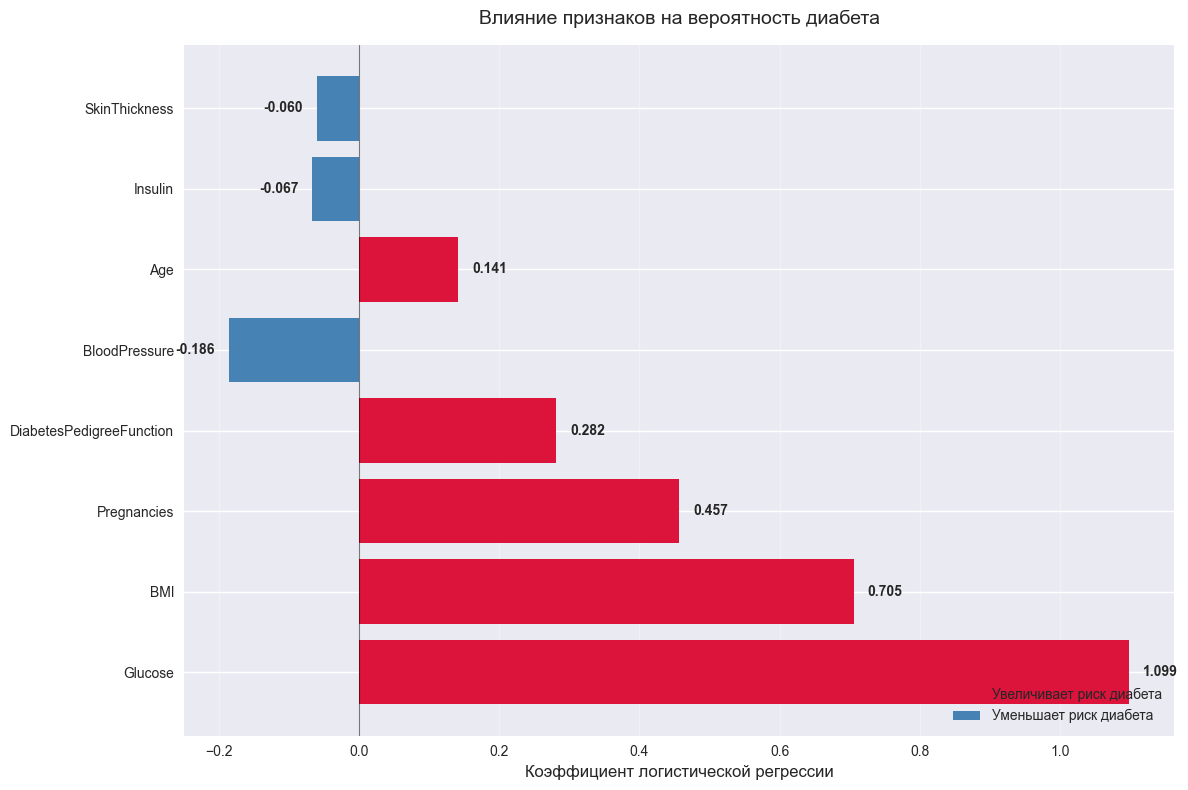

In [167]:
print("АНАЛИЗ КОЭФФИЦИЕНТОВ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ")
print("=" * 60)

coefficients = logreg.coef_[0]
intercept = logreg.intercept_[0]


coef_df = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент': coefficients,
    'Абс_Коэффициент': np.abs(coefficients),
    'exp(Коэффициент)': np.exp(coefficients)  
})

coef_df = coef_df.sort_values('Абс_Коэффициент', ascending=False)

print("Коэффициенты модели (отсортированы по важности):")
print(coef_df.to_string(index=False))

print(f"\nСвободный член (intercept): {intercept:.4f}")
print(f"exp(intercept) = {np.exp(intercept):.4f} (базовые шансы при средних значениях признаков)")

plt.figure(figsize=(12, 8))

colors = ['crimson' if coef > 0 else 'steelblue' for coef in coef_df['Коэффициент']]
bars = plt.barh(coef_df['Признак'], coef_df['Коэффициент'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

for bar, coef in zip(bars, coef_df['Коэффициент']):
    if coef >= 0:
        plt.text(coef + 0.02, bar.get_y() + bar.get_height()/2, 
                f'{coef:.3f}', ha='left', va='center', fontweight='bold')
    else:
        plt.text(coef - 0.02, bar.get_y() + bar.get_height()/2, 
                f'{coef:.3f}', ha='right', va='center', fontweight='bold')

plt.xlabel('Коэффициент логистической регрессии', fontsize=12)
plt.title('Влияние признаков на вероятность диабета', fontsize=14, pad=15)
plt.grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='crimson', label='Увеличивает риск диабета'),
    Patch(facecolor='steelblue', label='Уменьшает риск диабета')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

In [168]:
print("\n" + "=" * 70)
print("ИНТЕРПРЕТАЦИЯ КОЭФФИЦИЕНТОВ")
print("=" * 70)

print("📊 КЛЮЧЕВЫЕ ВЫВОДЫ:")

# Находим топ-3 положительных и отрицательных коэффициента
top_positive = coef_df[coef_df['Коэффициент'] > 0].head(3)
top_negative = coef_df[coef_df['Коэффициент'] < 0].head(3)

print("\n1. Признаки, СИЛЬНЕЕ ВСЕГО увеличивающие риск диабета:")
for _, row in top_positive.iterrows():
    odds_ratio = np.exp(row['Коэффициент'])
    print(f"   • {row['Признак']}: коэффициент = {row['Коэффициент']:.3f}")
    print(f"     Увеличение на 1σ повышает шансы в {odds_ratio:.2f} раз")
    print(f"     Вероятность диабета возрастает на {(odds_ratio-1)*100:.1f}% при увеличении признака на 1σ")

print("\n2. Признаки, СИЛЬНЕЕ ВСЕГО уменьшающие риск диабета:")
for _, row in top_negative.iterrows():
    odds_ratio = np.exp(row['Коэффициент'])
    print(f"   • {row['Признак']}: коэффициент = {row['Коэффициент']:.3f}")
    print(f"     Увеличение на 1σ уменьшает шансы в {1/odds_ratio:.2f} раз")
    print(f"     Вероятность диабета снижается на {(1-odds_ratio)*100:.1f}% при увеличении признака на 1σ")

print("\n3. Слабые влияния (коэффициент по модулю < 0.3):")
weak_features = coef_df[coef_df['Абс_Коэффициент'] < 0.3]
for _, row in weak_features.iterrows():
    direction = "увеличивает" if row['Коэффициент'] > 0 else "уменьшает"
    print(f"   • {row['Признак']}: слабо {direction} риск (коэфф = {row['Коэффициент']:.3f})")

print("\n4. Медицинская интерпретация:")
print("   • После стандартизации все признаки измеряются в 'стандартных отклонениях'")
print("   • Коэффициент показывает изменение log-odds при изменении признака на 1σ")
print("   • exp(коэффициент) = отношение шансов (Odds Ratio)")


ИНТЕРПРЕТАЦИЯ КОЭФФИЦИЕНТОВ
📊 КЛЮЧЕВЫЕ ВЫВОДЫ:

1. Признаки, СИЛЬНЕЕ ВСЕГО увеличивающие риск диабета:
   • Glucose: коэффициент = 1.099
     Увеличение на 1σ повышает шансы в 3.00 раз
     Вероятность диабета возрастает на 200.0% при увеличении признака на 1σ
   • BMI: коэффициент = 0.705
     Увеличение на 1σ повышает шансы в 2.02 раз
     Вероятность диабета возрастает на 102.5% при увеличении признака на 1σ
   • Pregnancies: коэффициент = 0.457
     Увеличение на 1σ повышает шансы в 1.58 раз
     Вероятность диабета возрастает на 57.9% при увеличении признака на 1σ

2. Признаки, СИЛЬНЕЕ ВСЕГО уменьшающие риск диабета:
   • BloodPressure: коэффициент = -0.186
     Увеличение на 1σ уменьшает шансы в 1.20 раз
     Вероятность диабета снижается на 17.0% при увеличении признака на 1σ
   • Insulin: коэффициент = -0.067
     Увеличение на 1σ уменьшает шансы в 1.07 раз
     Вероятность диабета снижается на 6.5% при увеличении признака на 1σ
   • SkinThickness: коэффициент = -0.060
     Ув

ВЫВОДЫ ИНТЕРПРЕТАЦИИ КОЭФФИЦИЕНТОВ:

1. Признаки, СИЛЬНЕЕ ВСЕГО увеличивающие риск диабета:   
   • Glucose: коэффициент = 1.099  
     Увеличение на 1σ повышает шансы в 3.00 раз  
     Вероятность диабета возрастает на 200.0% при увеличении признака на 1σ  
   • BMI: коэффициент = 0.705  
     Увеличение на 1σ повышает шансы в 2.02 раз  
     Вероятность диабета возрастает на 102.5% при увеличении признака на 1σ  
   • Pregnancies: коэффициент = 0.457  
     Увеличение на 1σ повышает шансы в 1.58 раз  
     Вероятность диабета возрастает на 57.9% при увеличении признака на 1σ  

2. Признаки, СИЛЬНЕЕ ВСЕГО уменьшающие риск диабета:   
   • BloodPressure: коэффициент = -0.186   
     Увеличение на 1σ уменьшает шансы в 1.20 раз   
     Вероятность диабета снижается на 17.0% при увеличении признака на 1σ   
   • Insulin: коэффициент = -0.067   
     Увеличение на 1σ уменьшает шансы в 1.07 раз   
     Вероятность диабета снижается на 6.5% при увеличении признака на 1σ   
   • SkinThickness: коэффициент = -0.060   
     Увеличение на 1σ уменьшает шансы в 1.06 раз   
     Вероятность диабета снижается на 5.9% при увеличении признака на 1σ   

3. Слабые влияния (коэффициент по модулю < 0.3):   
   • DiabetesPedigreeFunction: слабо увеличивает риск (коэфф = 0.282)   
   • BloodPressure: слабо уменьшает риск (коэфф = -0.186)   
   • Age: слабо увеличивает риск (коэфф = 0.141)   
   • Insulin: слабо уменьшает риск (коэфф = -0.067)   
   • SkinThickness: слабо уменьшает риск (коэфф = -0.060)   


In [169]:
print("СОЗДАНИЕ ФУНКЦИИ ДЛЯ ПРОГНОЗИРОВАНИЯ")
print("=" * 60)

def predict_diabetes(pregnancies, glucose, blood_pressure, skin_thickness, 
                    insulin, bmi, diabetes_pedigree_function, age,
                    model=logreg, scaler=scaler, threshold=0.5):
    
    input_data = pd.DataFrame({
        'Pregnancies': [pregnancies],
        'Glucose': [glucose],
        'BloodPressure': [blood_pressure],
        'SkinThickness': [skin_thickness],
        'Insulin': [insulin],
        'BMI': [bmi],
        'DiabetesPedigreeFunction': [diabetes_pedigree_function],
        'Age': [age]
    })
    
    input_scaled = scaler.transform(input_data)
    
    probabilities = model.predict_proba(input_scaled)[0]
    diabetes_prob = probabilities[1]  

    prediction = 1 if diabetes_prob >= threshold else 0
    
    risk_level = "НИЗКИЙ"
    recommendation = "Риск диабета низкий. Рекомендуется стандартный ежегодный скрининг."
    
    if diabetes_prob >= 0.7:
        risk_level = "ОЧЕНЬ ВЫСОКИЙ"
        recommendation = "Немедленно обратиться к врачу для дополнительного обследования."
    elif diabetes_prob >= 0.5:
        risk_level = "ВЫСОКИЙ"
        recommendation = "Рекомендуется срочная консультация эндокринолога."
    elif diabetes_prob >= 0.3:
        risk_level = "УМЕРЕННЫЙ"
        recommendation = "Рекомендуется дополнительное обследование в течение месяца."
    
    result = {
        'Вероятность диабета': float(diabetes_prob),
        'Прогноз': 'Диабет' if prediction == 1 else 'Нет диабета',
        'Уровень риска': risk_level,
        'Рекомендация': recommendation,
        'Порог классификации': threshold,
        'Вероятности по классам': {
            'Нет диабета': float(probabilities[0]),
            'Диабет': float(probabilities[1])
        }
    }
    
    return result

print("Функция predict_diabetes() великолепно создана!")
print("\nСигнатура функции:")
print("""predict_diabetes(pregnancies, glucose, blood_pressure, skin_thickness,
                 insulin, bmi, diabetes_pedigree_function, age,
                 model=logreg, scaler=scaler, threshold=0.5)""")

СОЗДАНИЕ ФУНКЦИИ ДЛЯ ПРОГНОЗИРОВАНИЯ
Функция predict_diabetes() великолепно создана!

Сигнатура функции:
predict_diabetes(pregnancies, glucose, blood_pressure, skin_thickness,
                 insulin, bmi, diabetes_pedigree_function, age,
                 model=logreg, scaler=scaler, threshold=0.5)


In [170]:
print("СОЗДАЙТЕ СВОЙ ПРИМЕР ДЛЯ ТЕСТИРОВАНИЯ")
print("=" * 70)
print("Введите данные пациента для оценки риска диабета:")


def interactive_test():  
    pregnancies = float(input("Количество беременностей: ") or 0)
    glucose = float(input("Уровень глюкозы (норма до 100): ") or 0)
    blood_pressure = float(input("Артериальное давление (норма ~120/80): ") or 0)
    skin_thickness = float(input("Толщина кожной складки (мм): ") or 0)
    insulin = float(input("Уровень инсулина (мкЕд/мл): ") or 0)
    bmi = float(input("Индекс массы тела BMI (норма 18.5-24.9): ") or 0)
    dpf = float(input("Функция наследственной предрасположенности (0.0-2.5): ") or 0)
    age = float(input("Возраст (лет): ") or 0)
    threshold = float(input("\nПорог классификации (по умолчанию 0.5): ") or 0.5)
        
    result = predict_diabetes(
            pregnancies, glucose, blood_pressure, skin_thickness,
            insulin, bmi, dpf, age, threshold=threshold
        )
        
    print("\n" + "=" * 60)
    print("РЕЗУЛЬТАТЫ ОЦЕНКИ РИСКА ДИАБЕТА")
    print("=" * 60)
         
    print(f"\nВероятность диабета: {result['Вероятность диабета']:.1%}")
    print(f"Прогноз: {result['Прогноз']}")
    print(f"Уровень риска: {result['Уровень риска']}")
    print(f"Рекомендация: {result['Рекомендация']}")
        
    print(f"\nДетализация:")
    print(f"  Вероятность отсутствия диабета: {result['Вероятности по классам']['Нет диабета']:.1%}")
    print(f"  Вероятность наличия диабета: {result['Вероятности по классам']['Диабет']:.1%}")
    print(f"  Использованный порог: {result['Порог классификации']}")
        
interactive_test()

СОЗДАЙТЕ СВОЙ ПРИМЕР ДЛЯ ТЕСТИРОВАНИЯ
Введите данные пациента для оценки риска диабета:


Количество беременностей:  10
Уровень глюкозы (норма до 100):  3
Артериальное давление (норма ~120/80):  200
Толщина кожной складки (мм):  9
Уровень инсулина (мкЕд/мл):  0
Индекс массы тела BMI (норма 18.5-24.9):  30
Функция наследственной предрасположенности (0.0-2.5):  5.0
Возраст (лет):  90

Порог классификации (по умолчанию 0.5):  0.5



РЕЗУЛЬТАТЫ ОЦЕНКИ РИСКА ДИАБЕТА

Вероятность диабета: 38.5%
Прогноз: Нет диабета
Уровень риска: УМЕРЕННЫЙ
Рекомендация: Рекомендуется дополнительное обследование в течение месяца.

Детализация:
  Вероятность отсутствия диабета: 61.5%
  Вероятность наличия диабета: 38.5%
  Использованный порог: 0.5


# Бонусное задание 9. Подбор гиперпараметров с использованием Grid Search

In [171]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
warnings.filterwarnings('ignore', category=FutureWarning)

In [172]:
print("ОПРЕДЕЛЕНИЕ СЕТКИ ГИПЕРПАРАМЕТРОВ")
print("=" * 60)

param_grid = [
    {
        'solver': ['lbfgs', 'liblinear'],
        'penalty': ['l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'class_weight': [None, 'balanced'],
        'max_iter': [1000]
    },
    {
        'solver': ['liblinear', 'saga'],
        'penalty': ['l1'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'class_weight': [None, 'balanced'],
        'max_iter': [1000]
    },
    {
        'solver': ['saga'],
        'penalty': ['elasticnet'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'l1_ratio': [0.1, 0.5, 0.9],
        'class_weight': [None, 'balanced'],
        'max_iter': [1000]
    }
]

print(" СЕТКА ГИПЕРПАРАМЕТРОВ ДЛЯ ПЕРЕБОРА:")
print(f"1. Параметр C (регуляризация): {param_grid[0]['C']}")
print(f"2. Типы регуляризации: L1, L2, ElasticNet")
print(f"3. Алгоритмы: lbfgs, liblinear, saga")
print(f"4. Балансировка классов: None, 'balanced'")

total_combinations = 0
for grid in param_grid:
    comb = 1
    for key, values in grid.items():
        comb *= len(values)
    total_combinations += comb

print(f"\n Всего комбинаций для перебора: {total_combinations}")
print(f"При 5-кратной кросс-валидации будет обучено: {total_combinations * 5} моделей")

ОПРЕДЕЛЕНИЕ СЕТКИ ГИПЕРПАРАМЕТРОВ
 СЕТКА ГИПЕРПАРАМЕТРОВ ДЛЯ ПЕРЕБОРА:
1. Параметр C (регуляризация): [0.001, 0.01, 0.1, 1, 10, 100]
2. Типы регуляризации: L1, L2, ElasticNet
3. Алгоритмы: lbfgs, liblinear, saga
4. Балансировка классов: None, 'balanced'

 Всего комбинаций для перебора: 84
При 5-кратной кросс-валидации будет обучено: 420 моделей


In [178]:
print("ВЫПОЛНЕНИЕ GRID SEARCH")
print("=" * 60)

import time

# Создаем GridSearchCV объект
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',           
    cv=5,                        
    n_jobs=-1,                   
    verbose=1,                   
    return_train_score=True      
)

grid_search.fit(X_train_scaled, y_train)

print(f"Лучшие параметры найдены!")


ВЫПОЛНЕНИЕ GRID SEARCH
Fitting 5 folds for each of 84 candidates, totalling 420 fits
Лучшие параметры найдены!


In [181]:
print("АНАЛИЗ РЕЗУЛЬТАТОВ GRID SEARCH")
print("=" * 60)
print("ЛУЧШИЕ ПАРАМЕТРЫ:")
best_params = grid_search.best_params_
for param, value in best_params.items():
    print(f"  {param:15}: {value}")

print(f"\nЛучший ROC-AUC на кросс-валидации: {grid_search.best_score_:.4f}")

results_df = pd.DataFrame(grid_search.cv_results_)
top_results = results_df.sort_values('mean_test_score', ascending=False).head(5)

print("\n ТОП-5:")
print("-" * 80)

for i, (_, row) in enumerate(top_results.iterrows(), 1):
    print(f"\n{i}. ROC-AUC: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")
    params = row['params']
    for key in ['C', 'penalty', 'solver', 'class_weight']:
        if key in params:
            print(f"   {key}: {params[key]}")
    if 'l1_ratio' in params:
        print(f"   l1_ratio: {params['l1_ratio']}")

АНАЛИЗ РЕЗУЛЬТАТОВ GRID SEARCH
ЛУЧШИЕ ПАРАМЕТРЫ:
  C              : 1
  class_weight   : None
  max_iter       : 1000
  penalty        : l2
  solver         : lbfgs

Лучший ROC-AUC на кросс-валидации: 0.8255

 ТОП-5:
--------------------------------------------------------------------------------

1. ROC-AUC: 0.8255 (±0.0254)
   C: 1
   penalty: l2
   solver: lbfgs
   class_weight: None

2. ROC-AUC: 0.8255 (±0.0261)
   C: 0.1
   penalty: elasticnet
   solver: saga
   class_weight: None
   l1_ratio: 0.1

3. ROC-AUC: 0.8255 (±0.0262)
   C: 1
   penalty: elasticnet
   solver: saga
   class_weight: None
   l1_ratio: 0.5

4. ROC-AUC: 0.8253 (±0.0256)
   C: 1
   penalty: l2
   solver: liblinear
   class_weight: None

5. ROC-AUC: 0.8252 (±0.0256)
   C: 1
   penalty: elasticnet
   solver: saga
   class_weight: None
   l1_ratio: 0.1


In [186]:
print("ОБУЧЕНИЕ МОДЕЛИ С ОПТИМАЛЬНЫМИ ПАРАМЕТРАМИ")
print("=" * 60)


best_model = grid_search.best_estimator_

y_pred_optimized = best_model.predict(X_test_scaled)
y_proba_optimized = best_model.predict_proba(X_test_scaled)[:, 1]

optimized_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_optimized),
    'precision': precision_score(y_test, y_pred_optimized),
    'recall': recall_score(y_test, y_pred_optimized),
    'f1': f1_score(y_test, y_pred_optimized),
    'roc_auc': roc_auc_score(y_test, y_proba_optimized)
}

print("МЕТРИКИ ОПТИМИЗИРОВАННОЙ МОДЕЛИ:")
for metric, value in optimized_metrics.items():
    print(f"  {metric:10}: {value:.4f}")


print(f"\nКоэффициенты оптимизированной модели:")
for feature, coef in zip(X.columns, best_model.coef_[0]):
    print(f"  {feature:25}: {coef:7.3f}")

ОБУЧЕНИЕ МОДЕЛИ С ОПТИМАЛЬНЫМИ ПАРАМЕТРАМИ
МЕТРИКИ ОПТИМИЗИРОВАННОЙ МОДЕЛИ:
  accuracy  : 0.7446
  precision : 0.6774
  recall    : 0.5185
  f1        : 0.5874
  roc_auc   : 0.8379

Коэффициенты оптимизированной модели:
  Pregnancies              :   0.456
  Glucose                  :   1.123
  BloodPressure            :  -0.202
  SkinThickness            :  -0.039
  Insulin                  :  -0.076
  BMI                      :   0.711
  DiabetesPedigreeFunction :   0.234
  Age                      :   0.096


In [199]:
print("СРАВНЕНИЕ МОДЕЛЕЙ: ДО vs ПОСЛЕ OPTIMIZATION")
print("=" * 60)

y_pred_base = base_model.predict(X_test_scaled)
y_proba_base = base_model.predict_proba(X_test_scaled)[:, 1]
base_metrics = {
        'accuracy': accuracy_score(y_test, y_pred_base),
        'precision': precision_score(y_test, y_pred_base),
        'recall': recall_score(y_test, y_pred_base),
        'f1': f1_score(y_test, y_pred_base),
        'roc_auc': roc_auc_score(y_test, y_proba_base)
    }
comparison_df = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Базовая модель': [
        base_metrics['accuracy'],
        base_metrics['precision'],
        base_metrics['recall'],
        base_metrics['f1'],
        base_metrics['roc_auc']
    ],
    'Оптимизированная модель': [
        optimized_metrics['accuracy'],
        optimized_metrics['precision'],
        optimized_metrics['recall'],
        optimized_metrics['f1'],
        optimized_metrics['roc_auc']
    ]
})

comparison_df['Разница'] = comparison_df['Оптимизированная модель'] - comparison_df['Базовая модель']
comparison_df['Улучшение (%)'] = (comparison_df['Разница'] / comparison_df['Базовая модель'] * 100).round(2)

print(" ТАБЛИЦА СРАВНЕНИЯ МЕТРИК:")
print(comparison_df.to_string(index=False))


print("\nАНАЛИЗ РЕЗУЛЬТАТОВ:")
print("-" * 40)

if 'grid_search' in locals():
    print(f"Лучшие параметры из Grid Search: {grid_search.best_params_}")
    print(f"Лучший ROC-AUC на кросс-валидации: {grid_search.best_score_:.4f}")

improvements = comparison_df[comparison_df['Разница'] > 0]
if len(improvements) > 0:
    print(f"\nУЛУЧШЕНИЯ ({len(improvements)} из 5 метрик):")
    for _, row in improvements.iterrows():
        print(f"  • {row['Метрика']}: +{row['Разница']:.4f} ({row['Улучшение (%)']}%)")

declines = comparison_df[comparison_df['Разница'] < 0]
if len(declines) > 0:
    print(f"\nУХУДШЕНИЯ ({len(declines)} метрик):")
    for _, row in declines.iterrows():
        print(f"  • {row['Метрика']}: {row['Разница']:.4f} ({row['Улучшение (%)']}%)")

# Общая оценка
roc_improvement = comparison_df.loc[comparison_df['Метрика'] == 'ROC-AUC', 'Разница'].values[0]
if roc_improvement > 0:
    print(f"\nОБЩИЙ ВЫВОД: Grid Search улучшил ROC-AUC на {roc_improvement:.4f}")
else:
    print(f"\nОБЩИЙ ВЫВОД: Grid Search не дал значительного улучшения ROC-AUC")


СРАВНЕНИЕ МОДЕЛЕЙ: ДО vs ПОСЛЕ OPTIMIZATION
 ТАБЛИЦА СРАВНЕНИЯ МЕТРИК:
  Метрика  Базовая модель  Оптимизированная модель   Разница  Улучшение (%)
 Accuracy        0.766234                 0.744589 -0.021645          -2.82
Precision        0.651685                 0.677419  0.025734           3.95
   Recall        0.716049                 0.518519 -0.197531         -27.59
 F1-score        0.682353                 0.587413 -0.094940         -13.91
  ROC-AUC        0.837695                 0.837942  0.000247           0.03

АНАЛИЗ РЕЗУЛЬТАТОВ:
----------------------------------------
Лучшие параметры из Grid Search: {'C': 1, 'class_weight': None, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Лучший ROC-AUC на кросс-валидации: 0.8255

УЛУЧШЕНИЯ (2 из 5 метрик):
  • Precision: +0.0257 (3.95%)
  • ROC-AUC: +0.0002 (0.03%)

УХУДШЕНИЯ (3 метрик):
  • Accuracy: -0.0216 (-2.82%)
  • Recall: -0.1975 (-27.59%)
  • F1-score: -0.0949 (-13.91%)

ОБЩИЙ ВЫВОД: Grid Search улучшил ROC-AUC на 0.

## Выводы о качестве работы новой модели и об эффективности метода Grid Search:
После работы с Grid Search на выходе получилась менее сбалансированная, но БОЛЕЕ "уверенная" модель.
модель сохранила хорошую различительную способность, но при этом снижает число ложных тревог - меньше здоровых людей получат ложный диагноз, а так же позволяет экономить ресурсы - меньше ненужных дополнительных обследований
ЭТО ПОБЕДА!!!!
